## ===================================================================================
### Loan Approval Prediction
### Author: Marcin Tylutki
## ===================================================================================
### The data in the project will be processed in accordance with the CRISP-DM methodology


#####
Banks and financial institutions receive many loan applications every day. Their goal is to decide which customers should receive a loan and which applications should be rejected.

#####
Making the right decision is important. Approving a loan for a risky customer can lead to financial loss. Rejecting a reliable customer can also be a missed business opportunity.

#####
Machine Learning can help make this process faster and more consistent.

## Business Problem

The company wants to build a model that can predict whether a loan application will be approved or rejected based on customer information.

This model could support loan officers during the decision-making process.

## My main objective

The goal of this project is to build a baseline Machine Learning models that predicts loan approval, compare their performance and also find the most important factors that affect the loan decision.


## Dataset Description

##### loan_id -                     Unique ID of the loan application.
##### no_of_dependents -            Number of people supported by the applicant.
##### education -                   Education level.
##### self_employed -               Shows if applicant is self-employed or not.
##### income_annum -                Annual income of the applicant.
##### loan_amount -                 Requested loan amount.
##### loan term -                   Loan repayment period.
##### cibil_score -                 Credit score, the higher the score the lower the risk of default
##### residential_assets_value -    Value of residential properties owned by the applicant.
##### commercial_assets_value -     Value of commercial properties owned by the applicant.
##### luxury_assets_value -         Value of luxury assets such as expensive cars or jewelry.
##### bank_asset_value -            Value of money and other assets held in banks.
##### loan_status -                 It shows whether the loan was Approved or Rejected. Oou target variable.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.tree import plot_tree


In [2]:
#Configuration

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
TEST_SIZE = 0.2

In [3]:
# Load data

df_loan = pd.read_csv("data/loan_approval_dataset.csv")
df_loan.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df_loan.shape

(4269, 13)

In [5]:
df_loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [6]:
# We can see above that every column name except loan_id has a space before a name, we'll quickly fix that.
df_loan.columns = df_loan.columns.str.strip()

In [7]:
df_loan.duplicated().sum()

np.int64(0)

In [8]:
df_loan.nunique().sort_values()

self_employed                  2
education                      2
loan_status                    2
no_of_dependents               6
loan_term                     10
income_annum                  98
bank_asset_value             146
commercial_assets_value      188
residential_assets_value     278
loan_amount                  378
luxury_assets_value          379
cibil_score                  601
loan_id                     4269
dtype: int64

In [9]:
for col in df_loan.select_dtypes('str'):
    print(df_loan[col].value_counts())
    print('-'*30)

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64
------------------------------
self_employed
Yes    2150
No     2119
Name: count, dtype: int64
------------------------------
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
------------------------------


In [10]:
df_loan.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


#### Observation
##### Most numerical values have a wide range of values. The minimum value of residential_assets_value is -100000, which looks unsual and requires investigation.

In [11]:
df_loan[df_loan["residential_assets_value"] < 0]

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
59,60,4,Not Graduate,Yes,5500000,18200000,16,797,-100000,4900000,18600000,4800000,Approved
196,197,4,Not Graduate,Yes,400000,1500000,2,669,-100000,600000,900000,500000,Approved
559,560,2,Graduate,Yes,200000,500000,6,885,-100000,0,300000,200000,Rejected
702,703,4,Graduate,Yes,6300000,23900000,6,899,-100000,11400000,20600000,6700000,Approved
737,738,2,Graduate,Yes,900000,2500000,16,458,-100000,100000,3200000,1100000,Rejected
784,785,0,Graduate,No,5000000,14400000,2,761,-100000,7300000,12600000,4500000,Approved
904,905,2,Graduate,No,4100000,14900000,12,571,-100000,5200000,13000000,3400000,Approved
1089,1090,3,Graduate,No,5100000,11000000,6,336,-100000,5800000,11600000,7500000,Rejected
1163,1164,2,Graduate,No,4500000,9100000,18,593,-100000,600000,12400000,2500000,Approved
1350,1351,5,Graduate,No,4000000,13700000,6,496,-100000,1400000,15800000,3700000,Rejected


In [12]:
len(df_loan.loc[df_loan["residential_assets_value"] < 0, 'loan_status'])

28

In [13]:
df_loan.loc[df_loan["residential_assets_value"] < 0, 'loan_status'].value_counts(normalize=True)

loan_status
Approved    0.571429
Rejected    0.428571
Name: proportion, dtype: float64

In [14]:
df_loan['loan_status'].value_counts(normalize=True)


loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64

### Data Quality Summary

##### In general data looks pretty clean:
      - Dataset contains 4269 records and 13 variables
      - There are no missing values found
      - Also no duplicated rows
      - Categorical variables contain consistent values.
      - The target variable is slightly imbalanced (approximately 62% Approved and 38% Rejected).
      - The residential_assets_value feature contains 28 records with value of -100000,they appear in both
        approved and rejected applications. Because they represent even less than 1% of our data I decided
        to keep it as it is.

### Data Distribution


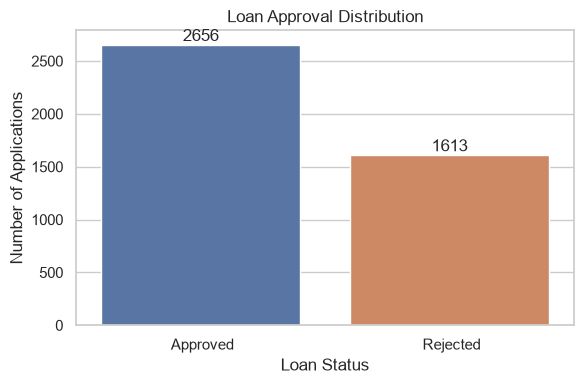

In [15]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df_loan,
    x="loan_status",
    hue="loan_status",
    legend=False
)

ax.set_title("Loan Approval Distribution")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Number of Applications")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

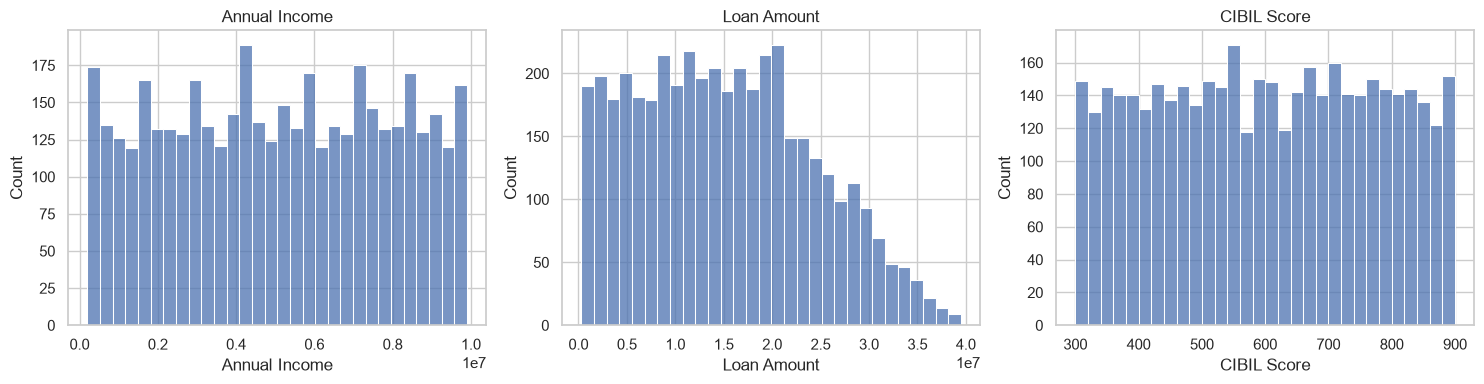

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

columns = ['income_annum', 'loan_amount', 'cibil_score']
titles = {
    "income_annum": "Annual Income",
    "loan_amount": "Loan Amount",
    "cibil_score": "CIBIL Score"
}

for index, col in enumerate(columns):

    sns.histplot(
        data=df_loan,
        x=col,
        bins=30,
        ax=axes[index]
    )

    axes[index].set_title(titles[col])
    axes[index].set_xlabel(titles[col])
    axes[index].set_ylabel("Count")

plt.tight_layout()
plt.show()

##### Annual income appears to be evenly distributed across the dataset, without any strong concentration around specific income range.
##### Loan amount shows a right-skewed distribution, indicating that at some point higher value loans become less common
##### CIBIL Score is relatively evenly distributed between approximately 300 and 900, showing that applicants have wide range of credit scores.

### Data Exploration - Relationship Between Numerical Features and Loan Status

The goal of this section is to find out whether or not numerical features have impact on approval or rejection loan applications. Understanding this may help identify variables that are important for predicting final decision.

#####

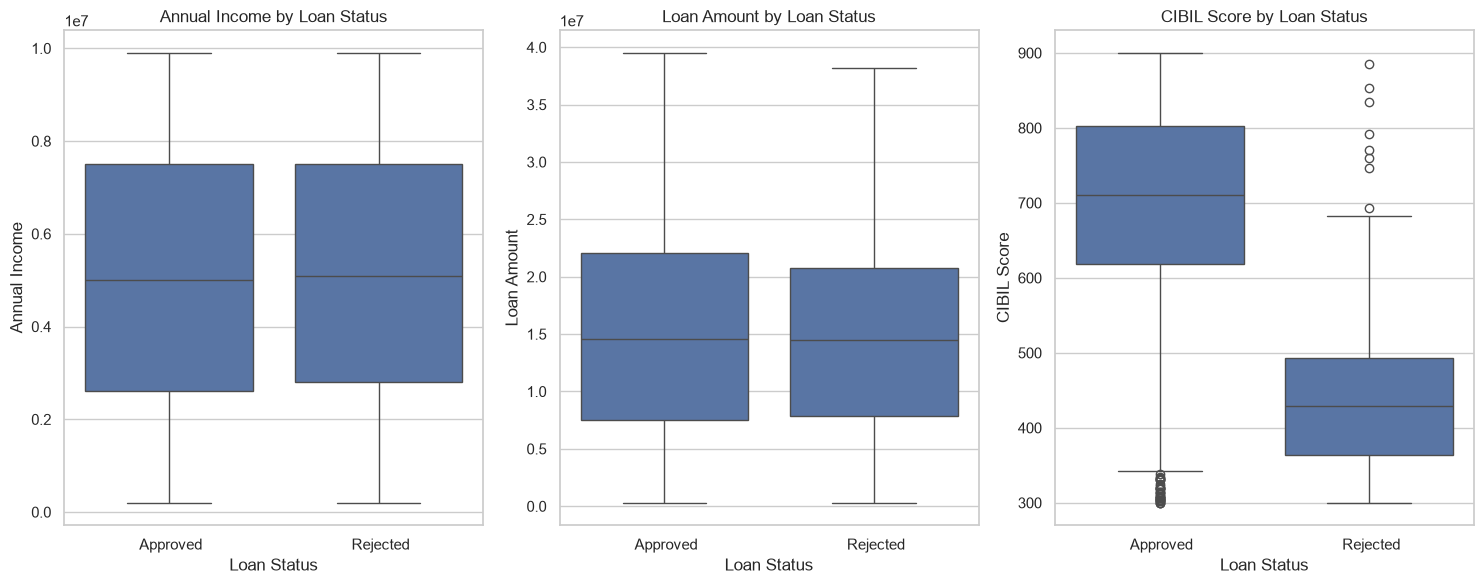

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 6))

for index, col in enumerate(columns):
    sns.boxplot(
        data=df_loan,
        x="loan_status",
        y=col,
        ax=ax[index]
    )

    ax[index].set_title(f"{titles[col]} by Loan Status")
    ax[index].set_xlabel("Loan Status")
    ax[index].set_ylabel(f"{titles[col]}")

plt.tight_layout()
plt.show()

In [18]:
df_loan.groupby("loan_status")[["income_annum",
                                "loan_amount",
                                "cibil_score"]].median()

,income_annum,loan_amount,cibil_score
loan_status,,,
Approved,5000000.0,14600000.0,711.0
Rejected,5100000.0,14500000.0,429.0


##### Annual income has a very similar distribution for both approved and rejected applications.
##### Loan amount also shows no clear visual difference between the two groups. We can see only slight difference in the medians, which also applies to annual income.
##### Applicants with approved loans generally have higher CIBIL scores than rejected applicants. This suggests that credit score may be an important factor in the loan approval process.

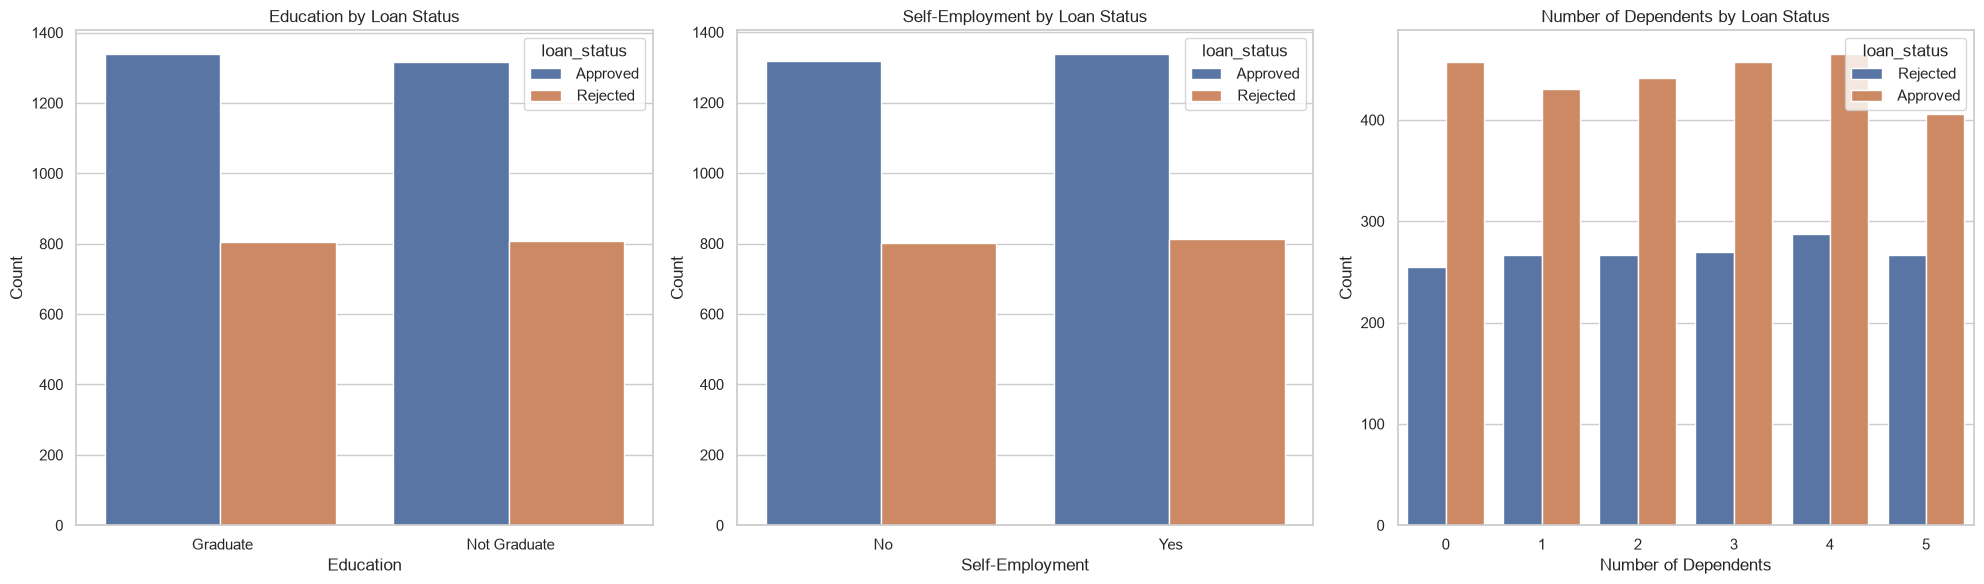

(np.float64(0.0), np.float64(179.55))

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

columns= ['education', 'self_employed', 'no_of_dependents']
titles = {
    'education': 'Education',
    'self_employed': 'Self-Employment',
    'no_of_dependents': 'Number of Dependents'
}

for index, col in enumerate(columns):
    sns.countplot(
        data= df_loan,
        x= col,
        hue= 'loan_status',
        ax=ax[index],
        legend=True
    )

    ax[index].set_title(f'{titles[col]} by Loan Status')
    ax[index].set_xlabel(titles[col])
    ax[index].set_ylabel("Count")

plt.tight_layout()
plt.show()
axes[index].get_ylim()

##### Based on the plots, there is no clear evidence that any of our categorical features have a strong relationship with loan approval. The proportions are very similar to each other across all categories.


###### Debugging note
###### While mapping the loan_status coulumn, I noticed that all the values were converted to NaN. After investigating the issue I found that the original values contained a space before the value - " Approved", " Rejected". Usage of str.strip() quickly fixed an issue.

###### Later in the project, I noticed the same pattern for categorical columns and applied the same solution.

In [20]:
df_loan['loan_status'] = df_loan['loan_status'].str.strip()
df_loan['education'] = df_loan['education'].str.strip()
df_loan['self_employed'] = df_loan['self_employed'].str.strip()

<Axes: >

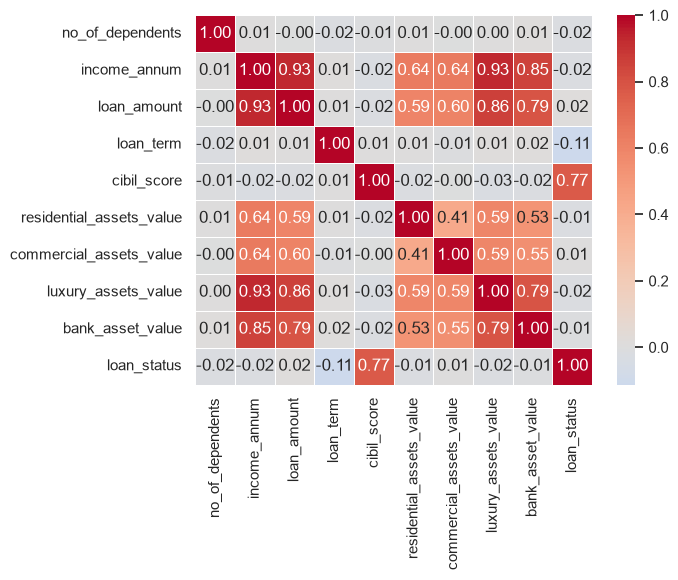

In [21]:
loan_status_map = {
    'Approved': 1,
    'Rejected': 0
}

df_corr = df_loan.copy()
df_corr['loan_status'] = df_corr['loan_status'].map(loan_status_map)

df_corr = df_corr.drop(columns=['loan_id', 'education', 'self_employed']).corr()
sns.heatmap(df_corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            linewidths=0.5)

##### Several financial variables show strong positive correlations. Applicants with higher annual income generally own more valuable assets and tend to apply for larger loans.
##### CIBIL score has the strongest positive correlation among all features confirming our observations from previous boxplots.

### Feature Engineering
The goal of this section is to create new features that may better represent an applicant's financial situation.

In [22]:
df_loan['loan_to_income'] = round(df_loan['loan_amount'] / df_loan['income_annum'], 2)
df_loan['loan_to_income'].head(20)

df_loan['total_assets'] = (
    df_loan['residential_assets_value'] +
    df_loan['commercial_assets_value'] +
    df_loan['luxury_assets_value'] +
    df_loan['bank_asset_value']
)

df_loan['loan_to_assets'] = round(df_loan['loan_amount'] / df_loan['total_assets'], 2)

df_loan['loan_to_assets'].head(20)

0     0.59
1     0.72
2     0.51
3     0.58
4     0.44
5     0.40
6     0.47
7     0.41
8     0.40
9     0.45
10    0.44
11    0.47
12    0.33
13    0.59
14    0.68
15    0.35
16    0.47
17    0.56
18    0.98
19    0.34
Name: loan_to_assets, dtype: float64

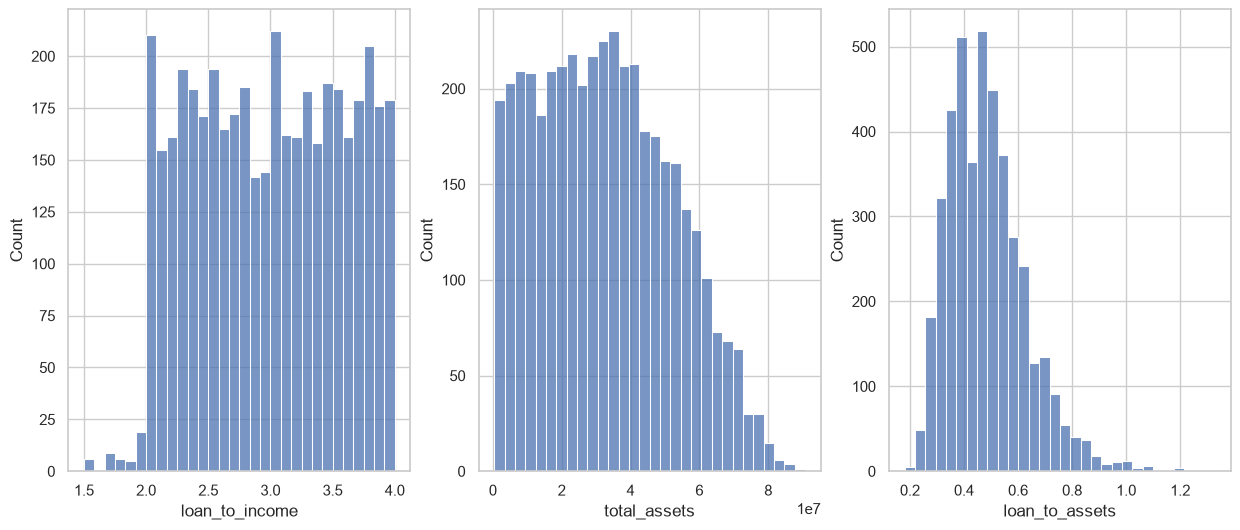

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(15,6))
cols_to_plot = ['loan_to_income', 'total_assets', 'loan_to_assets']

for index, col in enumerate(cols_to_plot):
    sns.histplot(data= df_loan,
                 x=col,
                 bins=30,
                 ax=ax[index])

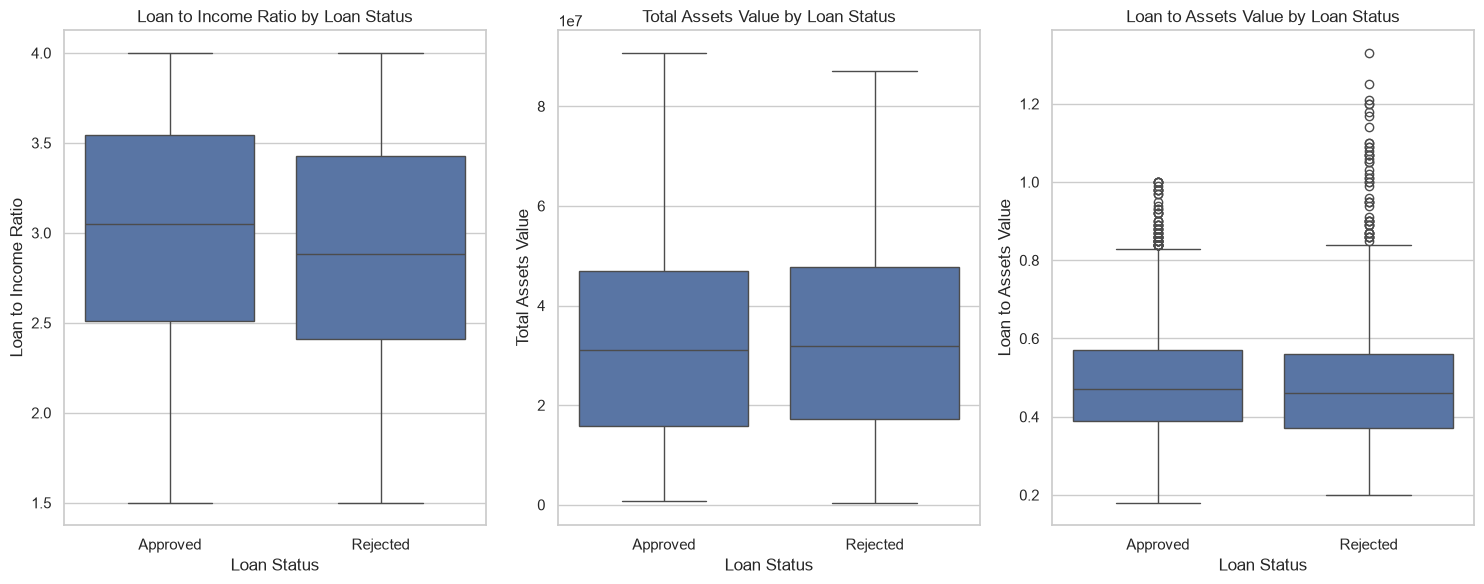

In [24]:
titles.update({
    "loan_to_income": "Loan to Income Ratio",
    "total_assets": "Total Assets Value",
    "loan_to_assets": "Loan to Assets Value"
})

fig, ax = plt.subplots(1, 3, figsize=(15, 6))

for index, col in enumerate(cols_to_plot):
    sns.boxplot(
        data=df_loan,
        x="loan_status",
        y=col,
        ax=ax[index]
    )

    ax[index].set_title(f"{titles[col]} by Loan Status")
    ax[index].set_xlabel("Loan Status")
    ax[index].set_ylabel(f"{titles[col]}")

plt.tight_layout()
plt.show()

In [25]:
df_loan["loan_to_income"].describe()

count    4269.000000
mean        2.984823
std         0.595546
min         1.500000
25%         2.460000
50%         3.000000
75%         3.500000
max         4.000000
Name: loan_to_income, dtype: float64

In [26]:
df_loan["loan_to_income"].min(), df_loan["loan_to_income"].max()

(np.float64(1.5), np.float64(4.0))

In [27]:
df_corr2 = df_loan.copy()
df_corr2['loan_status'] = df_corr2['loan_status'].map(loan_status_map)

df_corr2[["loan_to_income",
        "total_assets",
        "loan_to_assets",
        "loan_status"]].corr()

,loan_to_income,total_assets,loan_to_assets,loan_status
loan_to_income,1.000000,0.025031,0.656264,0.087714
total_assets,0.025031,1.000000,-0.251352,-0.011281
loan_to_assets,0.656264,-0.251352,1.000000,0.029440
loan_status,0.087714,-0.011281,0.029440,1.000000


##### Three new features were created based on buissness logic. Initial analysis showed that they have weak linear relationships with loan approval. Their usefulness will be tested during the model training stage.

### Data Preprocessing

In this section, the dataset is prepared for machine learning models. This includes selecting features and the target variable, encoding categorical variables, splitting the data into training and testing sets, and preparing the data for model training.

In [28]:
# df_loan['loan_status'] = df_loan.pop('loan_status')
education_map = {
    "Graduate": 1,
    "Not Graduate": 0
}

self_employment_map = {
    "Yes": 1,
    "No": 0
}



df_loan['education'] = df_loan['education'].map(education_map)
df_loan['self_employed'] = df_loan['self_employed'].map(self_employment_map)
df_loan['loan_status'] = df_loan['loan_status'].map(loan_status_map)

X = df_loan.drop(columns=['loan_id', 'loan_status'])
y = df_loan['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=RANDOM_STATE,
    test_size=TEST_SIZE
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(y_train.value_counts(normalize=True) *100)
print(y_test.value_counts(normalize=True) *100)

Training set: (3415, 14)
Testing set: (854, 14)
loan_status
1    62.225476
0    37.774524
Name: proportion, dtype: float64
loan_status
1    62.177986
0    37.822014
Name: proportion, dtype: float64


##### Categorical variables were encoded using simple mapping because each of them contains only two categories. More advanced encoding methods, such as one-hot encoding, were not necessary in this case.

## Logistic Regression

As the first baseline model, Logistic Regression was selected because it is simple and easy to interpret.


In [29]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:,1]

Accuracy:  0.91
Precision: 0.92
Recall:    0.94
F1-score:  0.93


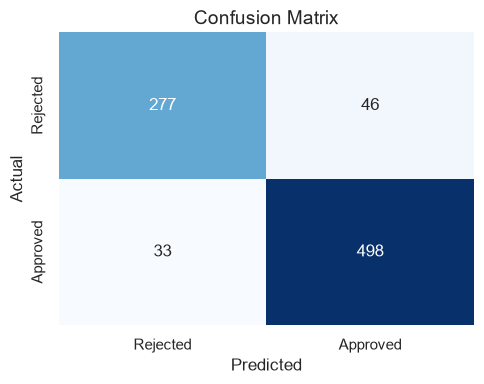

In [30]:
def evaluate_model(y_test, y_pred):
    """
    Prints basic model performance metrics and displays the confusion matrix.
    """
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.2f}")
    print(f"F1-score:  {f1_score(y_test, y_pred):.2f}")

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        data= cm,
        annot= True,
        annot_kws= {"size": 12},
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Rejected", "Approved"],
        yticklabels=["Rejected", "Approved"]
    )

    plt.title("Confusion Matrix", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

evaluate_model(y_test, y_pred_log)

##### The Logistic Regression model achieved strong overall performance, with high precision and recall. The confusion matrix shows that most loan applications were classified correctly, making this model a solid baseline for comparison with more advanced algorithms.

## Decision Tree

Decision Tree is the first non-linear model used in this project. It is able to model more complex relationships between features and works well without feature scaling.

Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1-score:  1.00


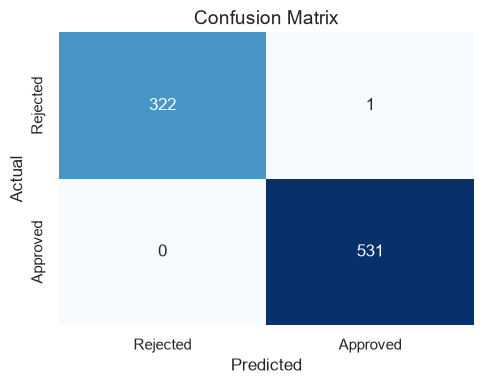

In [31]:
d_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

d_tree.fit(X_train, y_train)

y_pred_tree = d_tree.predict(X_test)
y_prob_tree = d_tree.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_tree)

In [32]:
print(f"Tree depth: {d_tree.get_depth()}")
print(f"Number of leaves: {d_tree.get_n_leaves()}")

Tree depth: 4
Number of leaves: 6


In [33]:
feature_importance = pd.Series(
    d_tree.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

cibil_score                 0.810427
loan_to_income              0.090911
loan_term                   0.083806
loan_to_assets              0.014856
education                   0.000000
no_of_dependents            0.000000
loan_amount                 0.000000
income_annum                0.000000
self_employed               0.000000
residential_assets_value    0.000000
luxury_assets_value         0.000000
commercial_assets_value     0.000000
bank_asset_value            0.000000
total_assets                0.000000
dtype: float64

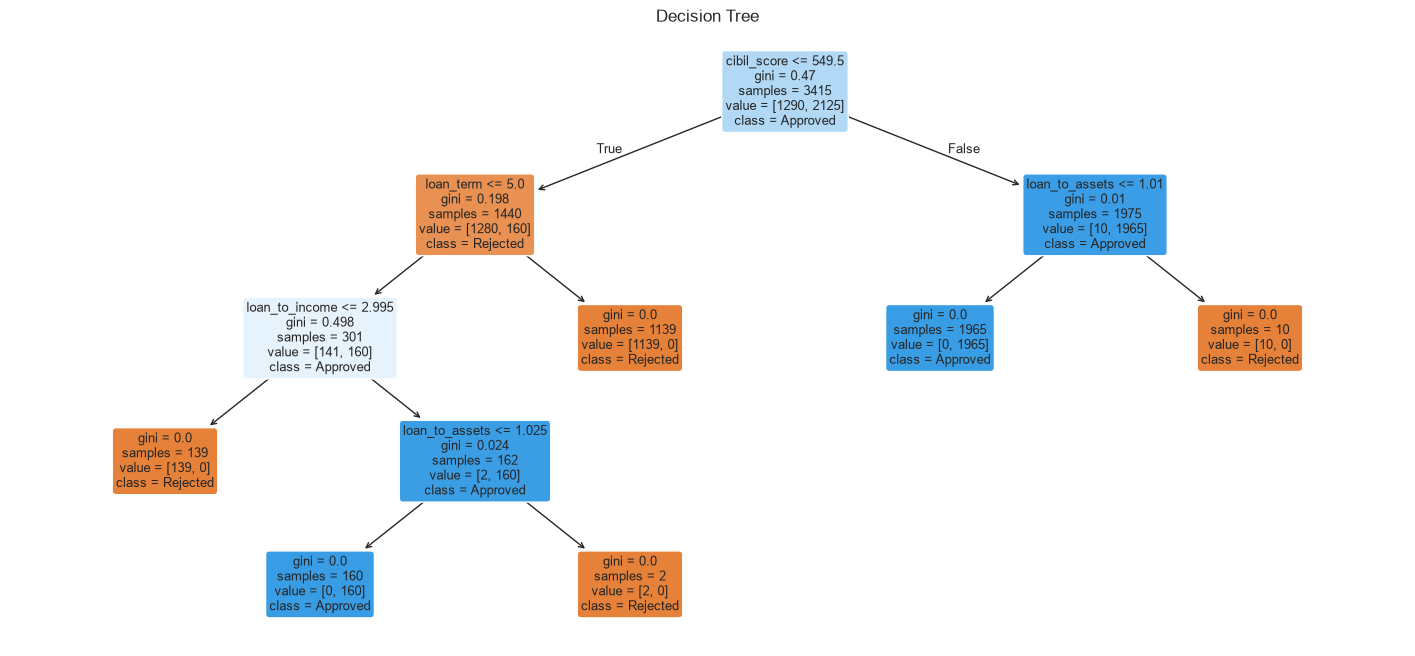

In [34]:
plt.figure(figsize=(18, 8))

plot_tree(
    d_tree,
    feature_names=X_train.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree")
plt.show()

The Decision Tree significantly outperformed Logistic Regression while remaining simple and easy to interpret. The model reached a depth of only four levels and correctly classified almost every loan application, suggesting that the decision process can be described using a small number of rules.

The first split is based on the applicant's CIBIL score, suggesting that credit history is the most important factor in the loan approval process. This finding is confirmed by the feature importance analysis. The engineered feature loan_to_assets was also used by the model, indicating that feature engineering contributed useful information.

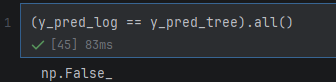

## Random Forest

After achieving almost perfect performance with a single Decision Tree, I expect Random Forest to achieve similar results. The main goal is to verify whether combining multiple trees provides any additional improvement on this dataset.

Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1-score:  1.00


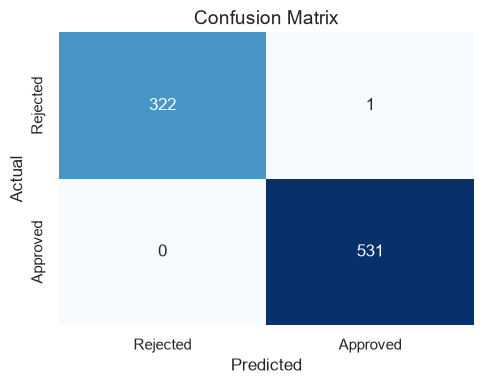

In [35]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_rf)

In [36]:
(y_pred_tree == y_pred_rf).all()

np.True_

In [37]:
print(accuracy_score(y_test, y_pred_log))
print(accuracy_score(y_test, y_pred_tree))
print(accuracy_score(y_test, y_pred_rf))

0.9074941451990632
0.9988290398126464
0.9988290398126464


In [38]:
print(f1_score(y_test, y_pred_log))
print(f1_score(y_test, y_pred_tree))
print(f1_score(y_test, y_pred_rf))

0.9265116279069767
0.9990592662276576
0.9990592662276576


In [39]:
pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

cibil_score                 0.789349
loan_term                   0.070055
loan_to_income              0.035390
loan_to_assets              0.021381
loan_amount                 0.013308
luxury_assets_value         0.011102
total_assets                0.011019
residential_assets_value    0.010712
commercial_assets_value     0.010676
income_annum                0.009701
bank_asset_value            0.009544
no_of_dependents            0.004713
education                   0.001583
self_employed               0.001466
dtype: float64

##### Although Random Forest produced the same predictions as the Decision Tree on the test set, the feature importance analysis shows that it distributed importance across a larger number of variables. This reflects the ensemble nature of the algorithm, where multiple trees contribute to the final prediction.

## Model Comparison

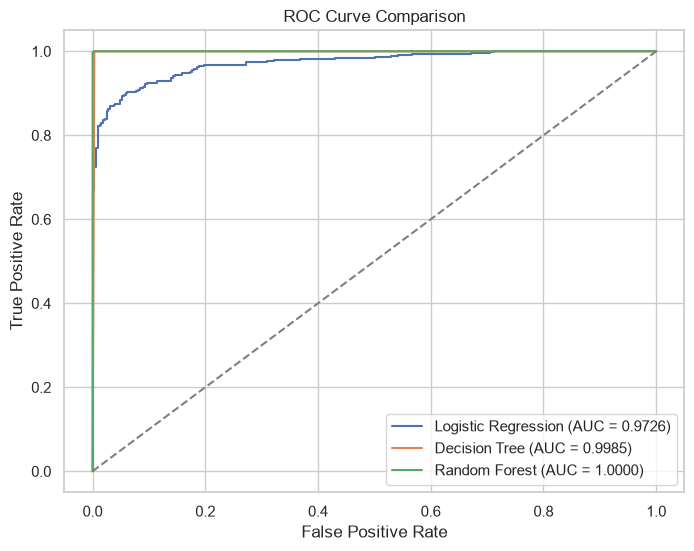

In [40]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.4f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {auc_tree:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

##### ROC AUC confirms the previous results. Logistic Regression performed well, but both tree-based models achieved higher AUC scores. Random Forest slightly outperformed Decision Tree, reaching a perfect AUC score of 1.0000.

## Project Summary

The objective of this project was to compare three popular machine learning algorithms for predicting loan approval decisions.

Among the evaluated models, Logistic Regression achieved good baseline performance with an accuracy of approximately 91%. However, both tree-based models significantly outperformed the linear model, achieving almost perfect classification on the test set.

The results suggest that the relationship between applicant characteristics and loan approval is non-linear. While Logistic Regression assumes a linear decision boundary, both Decision Tree and Random Forest were able to capture more complex relationships between the features.

## Key Findings

- CIBIL score was consistently identified as the most important feature throughout the project.
- The engineered feature `loan_to_assets` was selected by both tree-based models, confirming that feature engineering provided additional useful information.
- A shallow Decision Tree with only four levels achieved almost perfect performance, suggesting that the loan approval process can be described using a relatively small number of decision rules.
- Random Forest achieved the same predictive performance as the Decision Tree, indicating that increasing model complexity did not improve the final predictions for this dataset.
- The excellent performance achieved in this project is likely related to the characteristics of the dataset. Real-world loan approval data is usually more complex, so similar results should not be expected without further validation.

## Project Scope

The objective of this project was to compare the baseline performance of several popular classification models. Hyperparameter tuning was intentionally not performed because the focus was on understanding the strengths and weaknesses of different algorithms rather than maximizing predictive performance.

## Future Improvements

Possible next steps include:

- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Cross-validation for more robust model evaluation.
- Testing additional models such as XGBoost or LightGBM.
- Evaluating the models on a different loan approval dataset to assess their generalization ability.
- Exploring additional feature engineering techniques.

## Business Recommendation

Both tree-based models achieved excellent results. Since Decision Tree provided almost identical performance while being simpler and fully interpretable, it would be the preferred model for this dataset.